# Kernel and mixing-matrix options

Two structural choices distinguish MOOGP from a conventional multi-output GP:

  * **`orthogonal`** — when `True` (default), the latent kernels are
    orthogonalized against the trend, so the GP residual carries no signal
    the trend already explains. `False` gives a conventional squared-exponential
    multi-output GP.
  * **`Psi`** — the $p \times q$ mixing matrix that maps the `q` latent GPs to
    the `p` outputs. By default it is derived from the data (fast); you can also
    fix it or learn it.

This notebook explores both.

In [1]:
# !pip install moogp
# !pip install matplotlib

import numpy as np
import matplotlib.pyplot as plt

from moogp.model import MOOGP
from moogp.design import make_G
from moogp.datasets import (log_lhs_1d_rescaled,
                            generate_borehole_data_nd)
from moogp import evaluation

## 1. `orthogonal`: keeping the trend interpretable

When the input design is not evenly spaced, a plain GP and the linear trend can "trade off" where the
smooth kernel soaks up part of the slope, so the recovered trend coefficients
$\hat\beta$ drift away from the truth. The orthogonal kernel forbids the GP from
representing anything the trend already spans, keeping $\hat\beta$ honest.

To show this cleanly we need an unambiguous true trend. Each output is a known
line plus a smooth wiggle that we make orthogonal to $\{1, x\}$ — so the true trend we
put in is exactly the least-squares trend of the full signal. We sample it on a clustered design (points bunched near $x=1$,
sparse near $x=0$) and check how well each model recovers that line. The helper
isolates the fitted trend $g(x)^\top\hat\beta$ on the original scale.

In [2]:
def trend_on_raw_scale(model, Xstar):
    """Isolate the fitted linear trend g(x)ᵀβ̂ on the original output scale."""
    Xw = model._to_working_x(np.asarray(Xstar))
    Gs = make_G({"X_scaled": Xw}, model.terms,
                one_based=model.one_based, return_names=False)
    return model._from_working_mean(Gs @ model.cache["bhat"])


# Build data whose true linear trend is unambiguous: each output is an explicit
# line plus a smooth wiggle made orthogonal to {1, x}. Because the wiggle carries
# no linear part, the line we put in equals the least-squares trend of the signal.
rng = np.random.default_rng(0)
xg = np.linspace(0, 1, 400).reshape(-1, 1)
Gg = np.column_stack([np.ones(400), xg[:, 0]])

b_s, *_ = np.linalg.lstsq(Gg, np.sin(2 * np.pi * xg[:, 0]), rcond=None)   # the shape's linear part
def wiggle(x):                                                           # the part {1, x} can't represent
    return np.sin(2 * np.pi * x) - (b_s[0] + b_s[1] * x)
scale = wiggle(xg[:, 0]).std()

intercepts = np.array([2.0, 8.0, -3.0])
slopes     = np.array([12.0, -10.0, 6.0])
amps       = np.array([2.5, 2.0, 1.5])

def true_line(x): return intercepts + slopes * x[:, None]               # the true trend
def true_f(x):    return true_line(x) + amps * (wiggle(x) / scale)[:, None]

# Clustered design: points bunched near x=1, sparse near x=0.
n = 60
X = log_lhs_1d_rescaled(n, seed=3, xmin=1e-3, cluster="right")
Y = true_f(X[:, 0]) + rng.normal(0, [0.5, 0.4, 0.3], size=(n, 3))
data = {"X": X, "Y": Y}
trend_true = true_line(xg[:, 0])

m_ortho = MOOGP(terms=[None, 1], q=3, orthogonal=True)
m_ortho.fit(data, optimizer_opts={"maxiter": 400})
m_plain = MOOGP(terms=[None, 1], q=3, orthogonal=False)
m_plain.fit(data, optimizer_opts={"maxiter": 400})

# Compare the recovered trend (slope + RMSE against the true line) for each output.
t_ortho, t_plain = trend_on_raw_scale(m_ortho, xg), trend_on_raw_scale(m_plain, xg)
for j in range(3):
    eo = evaluation.rmse(trend_true[:, j], t_ortho[:, j])
    ep = evaluation.rmse(trend_true[:, j], t_plain[:, j])
    slope_o = t_ortho[-1, j] - t_ortho[0, j]     # slope over x in [0, 1]
    slope_p = t_plain[-1, j] - t_plain[0, j]
    print(f"output {j + 1}:  true slope={slopes[j]:6.1f} | "
          f"orthogonal={slope_o:6.1f} (RMSE {eo:4.2f})   "
          f"non-orthogonal={slope_p:6.1f} (RMSE {ep:4.2f})")

output 1:  true slope=  12.0 | orthogonal=  13.4 (RMSE 0.43)   non-orthogonal=  23.5 (RMSE 3.54)
output 2:  true slope= -10.0 | orthogonal=  -8.6 (RMSE 0.48)   non-orthogonal=   1.9 (RMSE 3.44)
output 3:  true slope=   6.0 | orthogonal=   7.1 (RMSE 0.34)   non-orthogonal=  13.2 (RMSE 2.19)


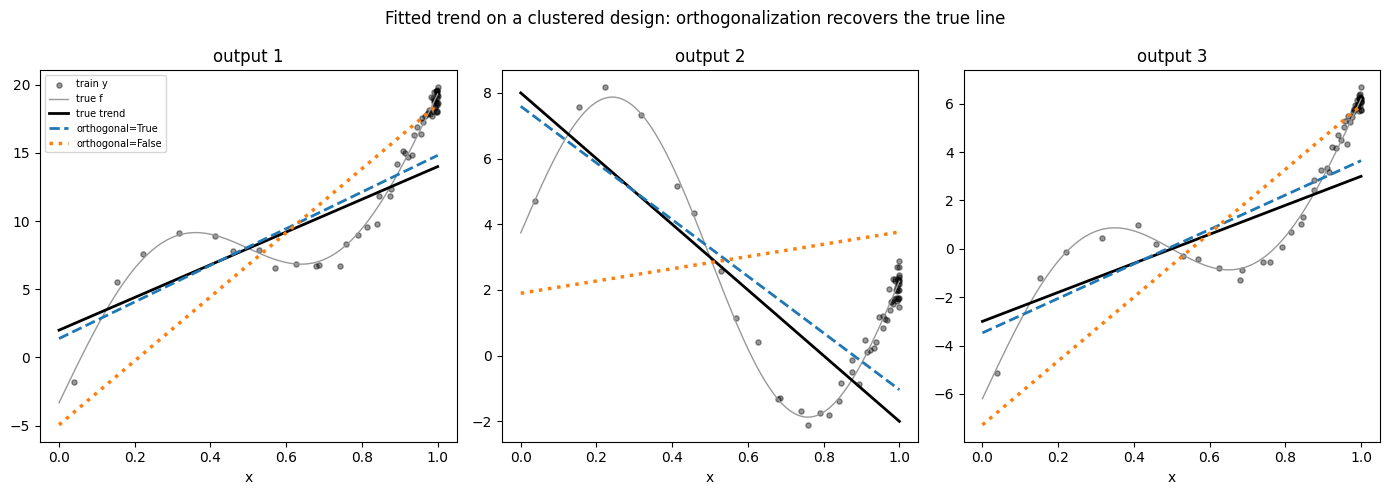

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True)
for j, ax in enumerate(axes):
    ax.scatter(X[:, 0], Y[:, j], s=14, c="k", alpha=0.4, label="train y")
    ax.plot(xg[:, 0], true_f(xg[:, 0])[:, j], color="0.6", lw=1, label="true f")
    ax.plot(xg[:, 0], trend_true[:, j], "k-", lw=2, label="true trend")
    ax.plot(xg[:, 0], t_ortho[:, j], "--", lw=2, color="tab:blue", label="orthogonal=True")
    ax.plot(xg[:, 0], t_plain[:, j], ":", lw=2.5, color="tab:orange", label="orthogonal=False")
    ax.set_title(f"output {j + 1}")
    ax.set_xlabel("x")
axes[0].legend(loc="best", fontsize=7)
fig.suptitle("Fitted trend on a clustered design: orthogonalization recovers the true line")
fig.tight_layout()

On every output the orthogonal model recovers the true line closely, while the
non-orthogonal trend is badly distorted — too steep on outputs 1 and 3, and even
the wrong sign on output 2. On this
clustered design the plain GP can't tell its own smooth variation apart from the
linear trend, so it soaks up trend signal and the reported slope stops meaning
what you think — and any extrapolation beyond the data inherits the error.

## 2. `Psi`: derived, fixed, or learned

The mixing matrix `Psi` can be supplied three ways. We compare them on the
borehole data and report whether each one uses the fast structure-exploiting
path.

In [4]:
bh = generate_borehole_data_nd(n=120, p=4, seed=67)
Xtr, Ytr = bh["X_scaled"][:90], bh["Y"][:90]
Xte, Yte = bh["X_scaled"][90:], bh["Y"][90:]
d, p, q = Xtr.shape[1], Ytr.shape[1], 4
terms = [None] + list(range(1, d + 1))

# A principled fixed Psi: the top-q output directions from the SVD of Y.
_, _, Vt = np.linalg.svd(Ytr - Ytr.mean(0), full_matrices=False)
Psi_svd = Vt[:q].T
Psi_svd /= np.linalg.norm(Psi_svd, axis=0, keepdims=True)

variants = {
    "derived (default)":     dict(),
    "fixed Psi (from SVD)":  dict(Psi=Psi_svd),
    "learn_Psi=True":        dict(learn_Psi=True),
}
for label, kw in variants.items():
    m = MOOGP(terms=terms, q=q, orthogonal=True, learn_sigma_eps=True,
              standardize_x=False, **kw)
    m.fit({"X": Xtr, "Y": Ytr}, optimizer_opts={"maxiter": 300})
    rmse = evaluation.rmse(Yte, m.predict(Xte))
    print(f"{label:22s}  used_fast={str(m.cache['used_fast']):5s}  test RMSE={rmse:.4f}")

derived (default)       used_fast=True   test RMSE=5.2297
fixed Psi (from SVD)    used_fast=False  test RMSE=87.1971
learn_Psi=True          used_fast=False  test RMSE=4.1181


  * **Derived (default)** rebuilds `Psi` from the SVD of `Y` each likelihood
    call and uses the fast Woodbury path — much faster for large `n` and `p`.
  * **Fixed `Psi`** pins the mixing to a known `(p, q)` matrix. Choose it
    sensibly (e.g. the SVD output directions above); an arbitrary/random `Psi`
    will underfit because the latent GPs cannot rotate to match the data.
  * **`learn_Psi=True`** optimizes `Psi` jointly. It is the most flexible but
    falls back to the dense path (`used_fast=False`) and is slower.

For most problems the default derived `Psi` is the right starting point.

### Takeaways

  * `orthogonal=True` keeps the trend coefficients honest and improves
    extrapolation; `False` is a conventional multi-output GP.
  * `Psi` defaults to a fast data-derived mixing; fix it (sensibly) to encode
    known structure, or set `learn_Psi=True` to learn it at extra cost.